# Firasa - EDA Notebook 02
## Cross-Dataset Exploratory Analysis

Firasa is trained on one dataset(DS1) and validated on others that were collected
entirely independently. The credibility of that strategy rests on a prior
question this notebook answers: *do the four datasets describe the same
underlying student behaviour, or four different worlds?* Here I map the schema
across all four sources, overlay the distributions of their shared features, and
quantify where those distributions agree and where they diverge. The headline
test is relationship consistency - if attendance and study time relate to exam
outcomes in the same direction across independently collected datasets, that is
evidence of a real signal rather than a quirk of one survey.

## 1. Setup and configuration

Load all four datasets through the validated loader and assemble the
dataset/column lookups from `config.CROSS_DATASET_FEATURE_MAP`. DS1
(`behavioral_analytics`) is the primary behavioral dataset but stores its
quantities as ordinal bands and carries a categorical risk label rather than a
numeric score, so it appears in the schema mapping but not in the numeric KDE
overlays, which require continuous values.

In [1]:
import logging
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def _find_project_root(start: Path) -> Path:
    """Locate the project root by walking up until ml/config.py is found."""
    for candidate in [start, *start.parents]:
        if (candidate / "ml" / "config.py").exists():
            return candidate
    raise RuntimeError(f"Could not locate the project root from {start}")


PROJECT_ROOT = _find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from ml import config
from data.data_loader import load_all_datasets

logging.basicConfig(
    level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s"
)
logger = logging.getLogger("eda_cross_dataset")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

datasets = load_all_datasets()
dfs = {
    "ds2": datasets["zenodo_merged"],
    "ds3": datasets["performance_prediction"],
    "ds4": datasets["performance_factors"],
}
LABELS = {"ds2": "DS2 (Zenodo)", "ds3": "DS3 (Prediction)", "ds4": "DS4 (Factors)"}
DATASET_KEYS = ("ds2", "ds3", "ds4")

FEATURE_MAP = config.CROSS_DATASET_FEATURE_MAP
TARGETS = config.CROSS_DATASET_REGRESSION_TARGETS

# Palette for the three numeric datasets.
DATASET_COLORS = {
    "DS2 (Zenodo)": config.BRAND_PRIMARY,
    "DS3 (Prediction)": config.RISK_PALETTE["Low Risk"],
    "DS4 (Factors)": config.RISK_PALETTE["High Risk"],
}


def save_plot(fig, filename: str) -> None:
    """Persist a figure to the plots directory, then display and close it."""
    output_path = config.PLOTS_DIR / filename
    fig.savefig(output_path, dpi=120, bbox_inches="tight")
    logger.info("Saved plot -> %s", output_path.name)
    plt.show()
    plt.close(fig)


def shared_series(canonical: str) -> dict:
    """Return {dataset_label: Series} for every dataset that has the feature."""
    series_by_label = {}
    for key in DATASET_KEYS:
        column = FEATURE_MAP[canonical][key]
        if column is not None:
            series_by_label[LABELS[key]] = dfs[key][column].dropna().astype(float)
    return series_by_label


def kde_overlay(title: str, filename: str, series_by_label: dict, normalize: bool = False) -> None:
    """Overlay kernel density estimates of several series on one axis."""
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for label, series in series_by_label.items():
        values = series.copy()
        if normalize:
            spread = values.std()
            values = (values - values.mean()) / spread if spread else values - values.mean()
        sns.kdeplot(
            values, label=label, ax=ax, linewidth=2, fill=True, alpha=0.12,
            color=DATASET_COLORS.get(label),
        )
    ax.set_title(title)
    ax.set_xlabel("standardised value (z-score)" if normalize else "value")
    ax.legend()
    plt.tight_layout()
    save_plot(fig, filename)


for key in DATASET_KEYS:
    logger.info("%s loaded: %d rows", LABELS[key], len(dfs[key]))

2026-06-22 23:22:38,410 | INFO | Loaded behavioral_analytics: 1200 rows x 36 columns from behavioral_analytics.csv


2026-06-22 23:22:38,411 | INFO | behavioral_analytics passed schema validation.


2026-06-22 23:22:38,418 | INFO | Loaded zenodo_merged: 14003 rows x 16 columns from zenodo_merged.csv


2026-06-22 23:22:38,418 | INFO | zenodo_merged passed schema validation.


2026-06-22 23:22:38,422 | INFO | Loaded performance_prediction: 10000 rows x 8 columns from performance_prediction.csv


...

2026-06-22 23:22:38,432 | INFO | Loaded performance_factors: 6607 rows x 20 columns from performance_factors.csv


2026-06-22 23:22:38,433 | INFO | performance_factors passed schema validation.


2026-06-22 23:22:38,433 | INFO | DS2 (Zenodo) loaded: 14003 rows


2026-06-22 23:22:38,434 | INFO | DS3 (Prediction) loaded: 10000 rows


2026-06-22 23:22:38,434 | INFO | DS4 (Factors) loaded: 6607 rows


## 2. Cross-dataset schema mapping

The four datasets use different column names and granularities for the same
concepts. The table below aligns them. DS1 stores its quantities as ordinal
bands (e.g. "76% – 85%" attendance) and its outcome as a categorical risk level,
so it is shown for completeness but excluded from the numeric overlays.

| Concept | DS1 (behavioral) | DS2 (zenodo) | DS3 (prediction) | DS4 (factors) | Numerically comparable |
|---|---|---|---|---|---|
| Study time | study_hours_daily (band) | StudyHours | study_hours | Hours_Studied | DS2–DS4 (scales differ) |
| Attendance | attendance_percentage (band) | Attendance | attendance | Attendance | DS2–DS4 (all %) |
| Assignment completion | assignments_on_time (ord.) | AssignmentCompletion | assignments_completed | - | DS2, DS3 (scales differ) |
| Prior performance | cgpa_category (band) | - | previous_score | Previous_Scores | DS3, DS4 (0–100) |
| Sleep | sleep_hours (band) | - | sleep_hours | Sleep_Hours | DS3, DS4 (hours) |
| Motivation | preparation_status (ord.) | Motivation | - | Motivation_Level | conceptual only |
| Stress | stress_level (1–5) | StressLevel | - | - | conceptual only |
| Extracurricular | events_participation (ord.) | Extracurricular | - | Extracurricular_Activities | conceptual only |
| Outcome | performance_risk_level (class) | ExamScore | exam_score | Exam_Score | DS2–DS4 numeric |

The numeric portion is sourced directly from a single source `config.CROSS_DATASET_FEATURE_MAP`
so the notebook and the cross-validator cannot drift apart. The only purpose of sourcing data from a set source is to ensure that everytime i het the same consistent data.

In [ ]:
mapping_rows = []
for canonical, columns in FEATURE_MAP.items():
    mapping_rows.append(
        {
            "canonical_feature": canonical,
            "DS2": columns["ds2"] or "-",
            "DS3": columns["ds3"] or "-",
            "DS4": columns["ds4"] or "-",
        }
    )
mapping_rows.append(
    {
        "canonical_feature": "exam_score (target)",
        "DS2": TARGETS["ds2"],
        "DS3": TARGETS["ds3"],
        "DS4": TARGETS["ds4"],
    }
)
mapping_df = pd.DataFrame(mapping_rows)
mapping_df

,canonical_feature,DS2,DS3,DS4
0,study_hours,StudyHours,study_hours,Hours_Studied
1,attendance,Attendance,attendance,Attendance
2,assignment_completion,AssignmentCompletion,assignments_completed,—
3,previous_score,—,previous_score,Previous_Scores
4,sleep_hours,—,sleep_hours,Sleep_Hours
5,exam_score (target),ExamScore,exam_score,Exam_Score


## 3. Shared-feature distributions (KDE overlays)

For every shared feature, the kernel density estimates from each dataset are
overlaid on one axis. Two views are produced: the **raw** overlay exposes
differences in measurement scale (the surveys recorded study time over different
periods, for example), while the **standardised** overlay (z-score) removes
scale so the *shape* of each distribution can be compared directly.

2026-06-22 23:22:38,681 | INFO | Saved plot -> EDA_02_kde_study_hours.png


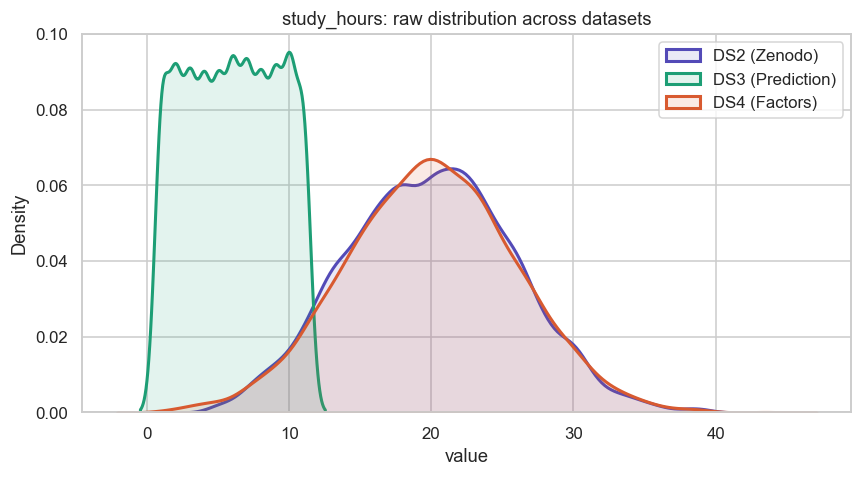

2026-06-22 23:22:38,885 | INFO | Saved plot -> EDA_02_kde_study_hours_norm.png


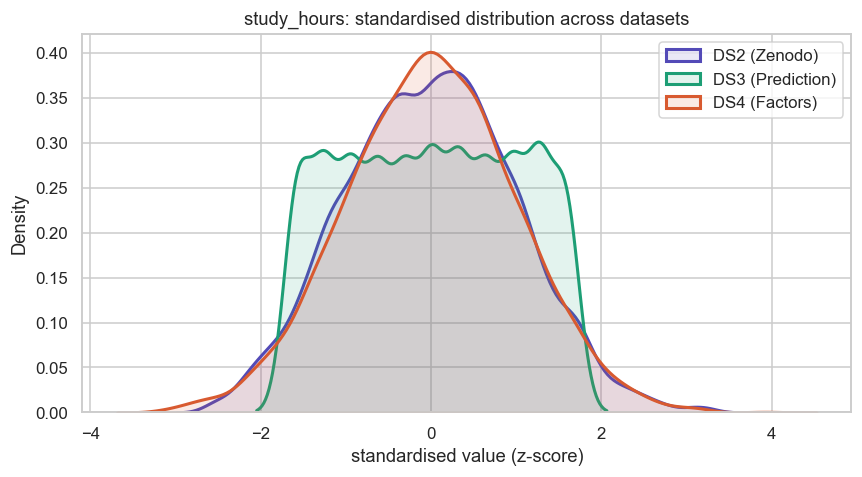

2026-06-22 23:22:39,087 | INFO | Saved plot -> EDA_02_kde_attendance.png


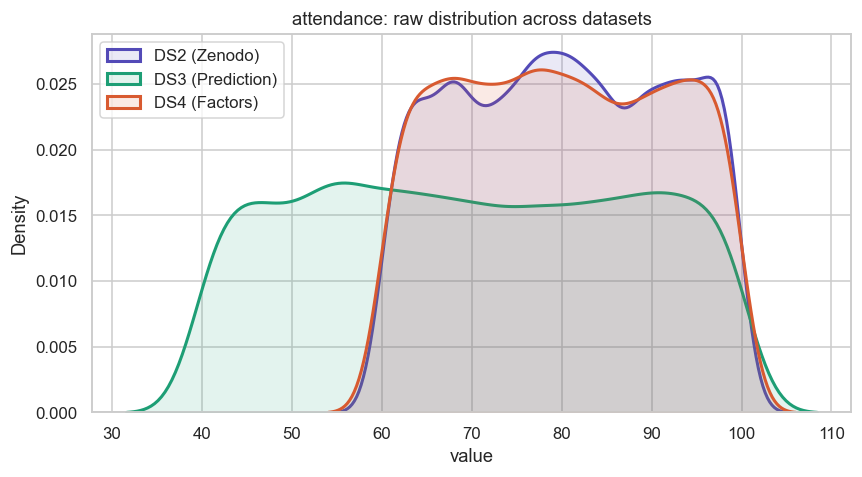

2026-06-22 23:22:39,286 | INFO | Saved plot -> EDA_02_kde_attendance_norm.png


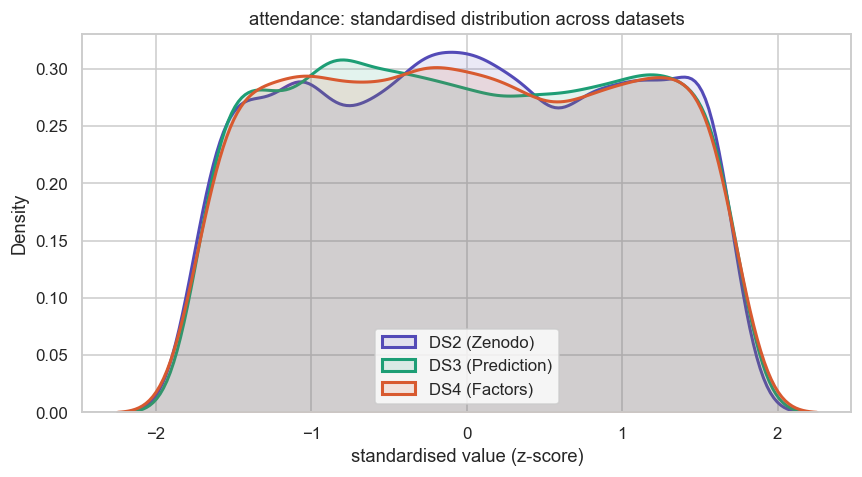

2026-06-22 23:22:39,464 | INFO | Saved plot -> EDA_02_kde_assignment_completion.png


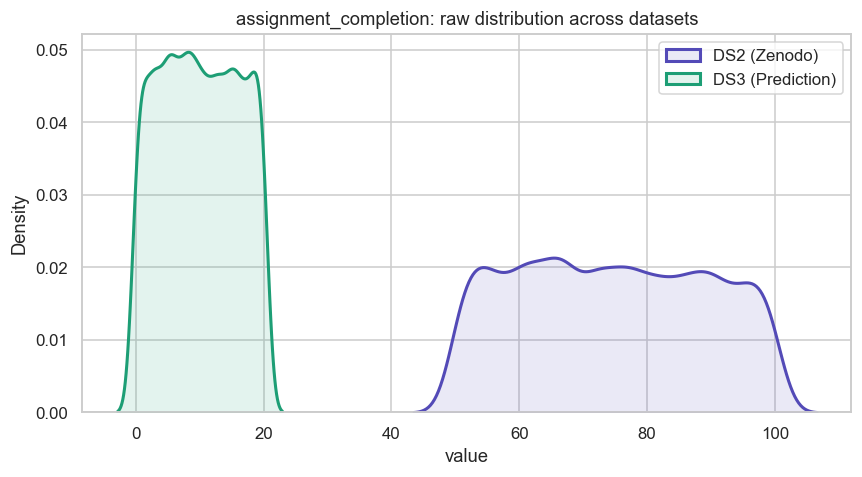

2026-06-22 23:22:39,644 | INFO | Saved plot -> EDA_02_kde_assignment_completion_norm.png


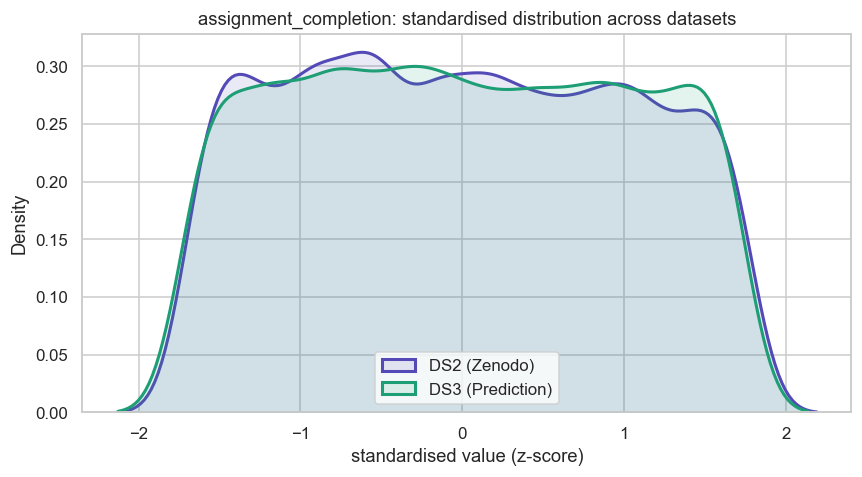

2026-06-22 23:22:39,832 | INFO | Saved plot -> EDA_02_kde_previous_score.png


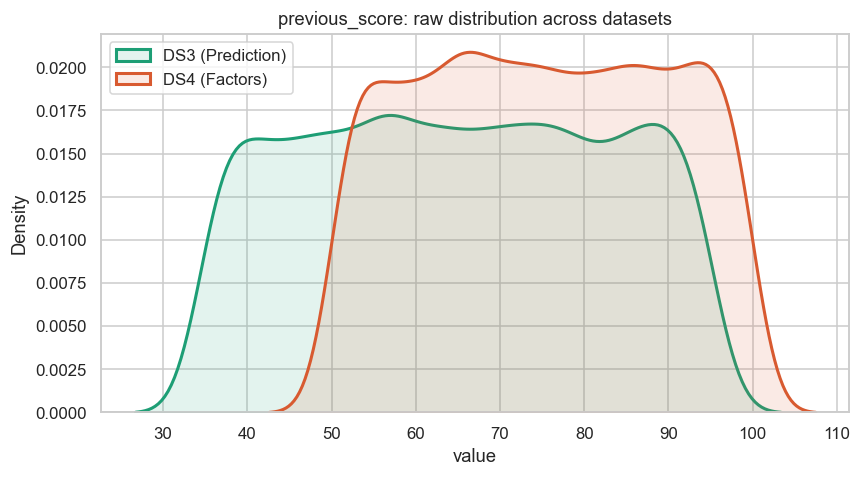

2026-06-22 23:22:40,013 | INFO | Saved plot -> EDA_02_kde_previous_score_norm.png


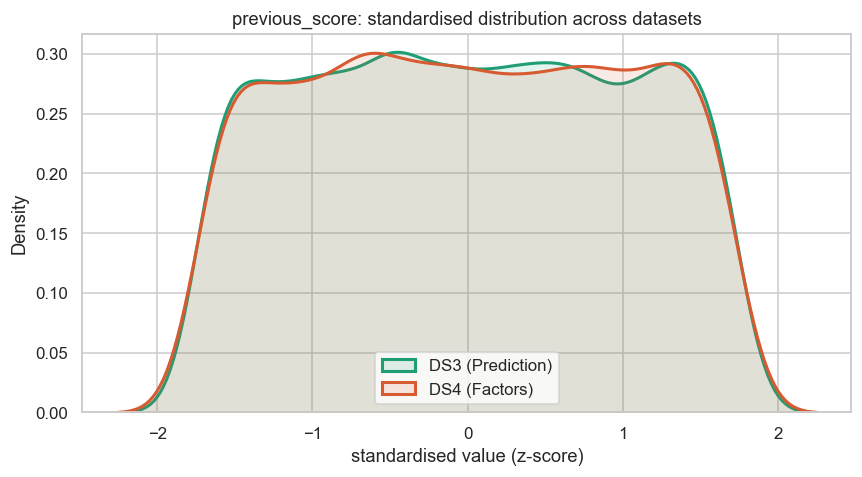

2026-06-22 23:22:40,195 | INFO | Saved plot -> EDA_02_kde_sleep_hours.png


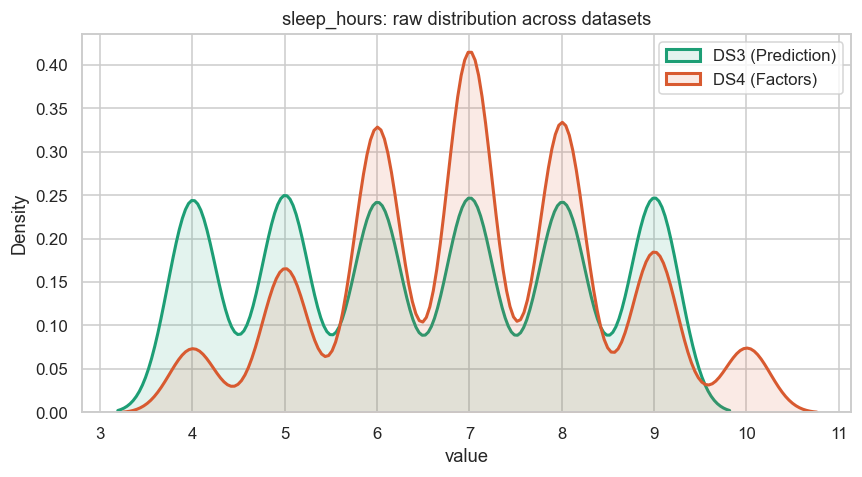

2026-06-22 23:22:40,372 | INFO | Saved plot -> EDA_02_kde_sleep_hours_norm.png


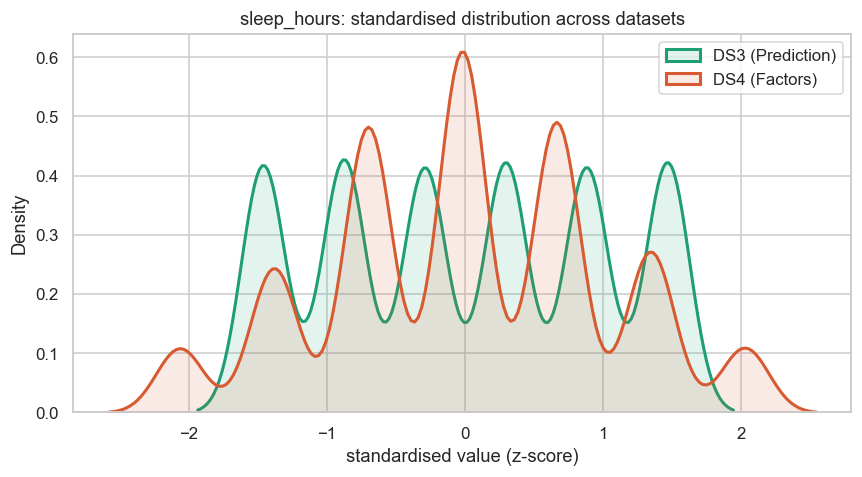

In [3]:
for canonical in FEATURE_MAP:
    series_by_label = shared_series(canonical)
    if len(series_by_label) < 2:
        continue
    kde_overlay(
        f"{canonical}: raw distribution across datasets",
        f"EDA_02_kde_{canonical}.png",
        series_by_label,
        normalize=False,
    )
    kde_overlay(
        f"{canonical}: standardised distribution across datasets",
        f"EDA_02_kde_{canonical}_norm.png",
        series_by_label,
        normalize=True,
    )

## 4. Outcome distribution across datasets

The regression target (exam score) is present in DS2, DS3, and DS4 on a roughly
0–100 scale. Comparing these directly shows whether the outcome variable itself
is consistently distributed across independent sources.

2026-06-22 23:22:40,560 | INFO | Saved plot -> EDA_02_target_examscore.png


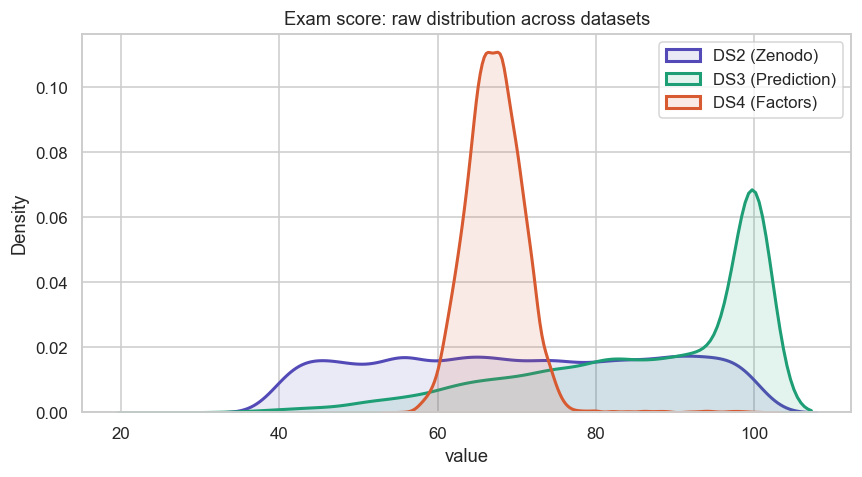

2026-06-22 23:22:40,748 | INFO | Saved plot -> EDA_02_target_examscore_norm.png


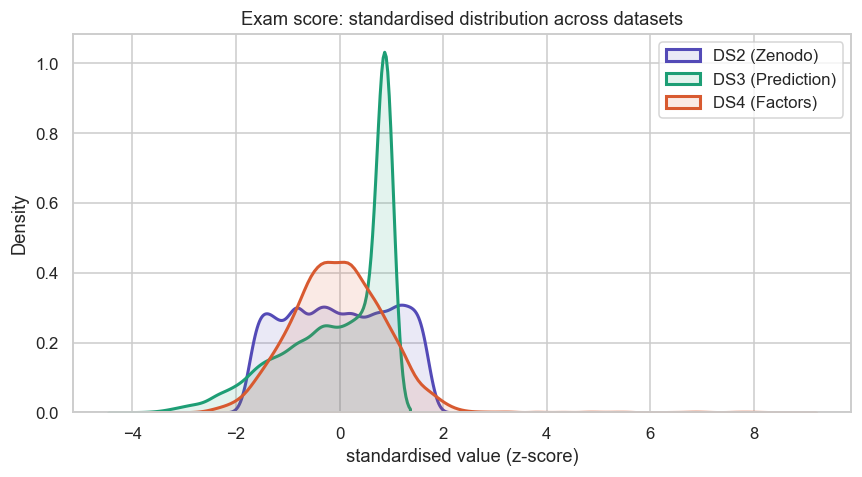

In [4]:
target_series = {
    LABELS[key]: dfs[key][TARGETS[key]].dropna().astype(float) for key in DATASET_KEYS
}
kde_overlay(
    "Exam score: raw distribution across datasets",
    "EDA_02_target_examscore.png",
    target_series,
    normalize=False,
)
kde_overlay(
    "Exam score: standardised distribution across datasets",
    "EDA_02_target_examscore_norm.png",
    target_series,
    normalize=True,
)

## 5. Distribution agreement - summary statistics

Mean, standard deviation, range, and sample size for every shared feature in
every dataset that contains it. Features measured on the same scale (attendance,
prior score, sleep, exam score) should show similar centres; features measured
over different periods (study time) will differ in centre but can still agree in
shape after standardisation.

In [5]:
summary_rows = []
for canonical, columns in FEATURE_MAP.items():
    for key in DATASET_KEYS:
        column = columns[key]
        if column is None:
            continue
        values = dfs[key][column].dropna().astype(float)
        summary_rows.append(
            {
                "feature": canonical,
                "dataset": LABELS[key],
                "mean": round(values.mean(), 2),
                "std": round(values.std(), 2),
                "min": round(values.min(), 2),
                "max": round(values.max(), 2),
                "n": len(values),
            }
        )
summary_df = pd.DataFrame(summary_rows)
summary_df

,feature,dataset,mean,std,min,max,n
0,study_hours,DS2 (Zenodo),19.99,5.89,5.0,44.0,14003
1,study_hours,DS3 (Prediction),5.99,3.16,1.0,11.0,10000
2,study_hours,DS4 (Factors),19.98,5.99,1.0,44.0,6607
3,attendance,DS2 (Zenodo),80.19,11.47,60.0,100.0,14003
4,attendance,DS3 (Prediction),69.88,17.62,40.0,100.0,10000
5,attendance,DS4 (Factors),79.98,11.55,60.0,100.0,6607
6,assignment_completion,DS2 (Zenodo),74.50,14.63,50.0,100.0,14003
7,assignment_completion,DS3 (Prediction),9.99,6.03,0.0,20.0,10000
8,previous_score,DS3 (Prediction),64.91,17.50,35.0,95.0,10000
9,previous_score,DS4 (Factors),75.07,14.40,50.0,100.0,6607


## 6. Relationship consistency (feature vs exam score)

This is the core external-validation evidence. For each shared feature I compute
its correlation with the exam-score outcome *within each dataset separately*. If
a feature relates to outcomes in the same direction across datasets that were
never pooled, the relationship is robust rather than dataset-specific. It tells me how strongly a feature is aligning overall instead of just trusting a single dataset conclusions. 

2026-06-22 23:22:40,925 | INFO | Saved plot -> EDA_02_corr_consistency.png


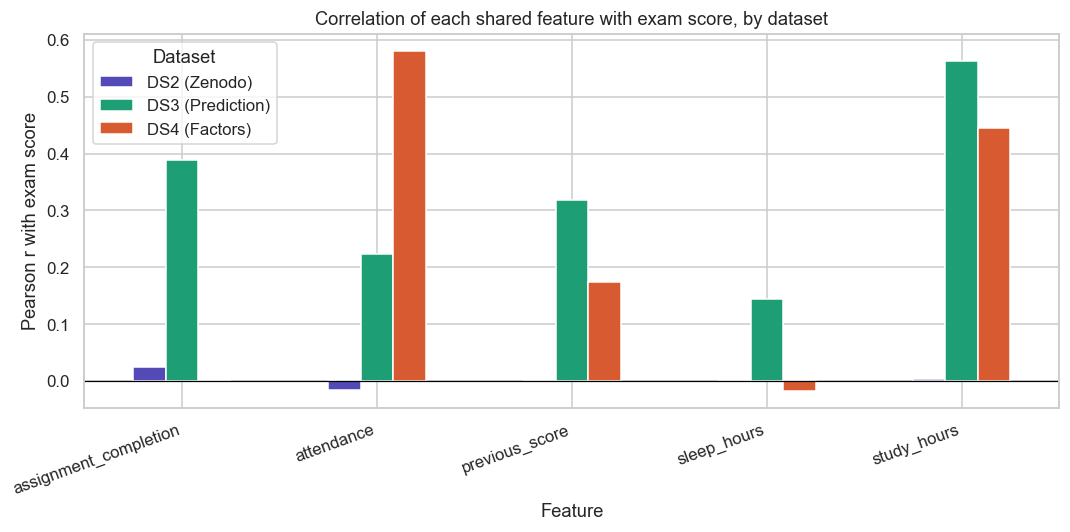

dataset,DS2 (Zenodo),DS3 (Prediction),DS4 (Factors)
feature,,,
assignment_completion,0.025,0.388,NaN
attendance,-0.015,0.223,0.581
previous_score,NaN,0.319,0.175
sleep_hours,NaN,0.145,-0.017
study_hours,0.004,0.563,0.445


In [6]:
corr_rows = []
for canonical, columns in FEATURE_MAP.items():
    for key in DATASET_KEYS:
        column = columns[key]
        if column is None:
            continue
        coefficient = dfs[key][column].corr(dfs[key][TARGETS[key]])
        corr_rows.append(
            {"feature": canonical, "dataset": LABELS[key], "corr_with_exam": round(coefficient, 3)}
        )

corr_df = pd.DataFrame(corr_rows)
corr_pivot = corr_df.pivot(index="feature", columns="dataset", values="corr_with_exam")

ax = corr_pivot.plot(
    kind="bar",
    figsize=(10, 5),
    color=[DATASET_COLORS.get(col) for col in corr_pivot.columns],
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Correlation of each shared feature with exam score, by dataset")
ax.set_ylabel("Pearson r with exam score")
ax.set_xlabel("Feature")
ax.legend(title="Dataset")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
save_plot(ax.get_figure(), "EDA_02_corr_consistency.png")
corr_pivot.round(3)

### 6b. Signal strength within each dataset

A directional comparison only means something if each dataset carries signal to
begin with. For every dataset I measure how strongly its own modelling features
correlate with its own exam-score target. This exposes a critical asymmetry that
directly affects the choice of regression training source.

In [7]:
signal_features = {
    "ds2": config.DS2_FEATURES,
    "ds3": [col for col in dfs["ds3"].select_dtypes("number").columns if col != TARGETS["ds3"]],
    "ds4": [col for col in dfs["ds4"].select_dtypes("number").columns if col != TARGETS["ds4"]],
}
signal_rows = []
for key in DATASET_KEYS:
    feature_corrs = dfs[key][signal_features[key]].corrwith(dfs[key][TARGETS[key]]).abs()
    signal_rows.append(
        {
            "dataset": LABELS[key],
            "n_numeric_features": len(signal_features[key]),
            "max_abs_corr": round(feature_corrs.max(), 3),
            "mean_abs_corr": round(feature_corrs.mean(), 3),
        }
    )

for row in signal_rows:
    if row["max_abs_corr"] < 0.1:
        logger.warning(
            "%s carries no usable signal: strongest feature/exam correlation is only %.3f.",
            row["dataset"], row["max_abs_corr"],
        )
    else:
        logger.info(
            "%s carries usable signal: strongest feature/exam correlation is %.3f.",
            row["dataset"], row["max_abs_corr"],
        )

signal_df = pd.DataFrame(signal_rows)
signal_df

2026-06-22 23:22:40,997 | WARNING | DS2 (Zenodo) carries no usable signal: strongest feature/exam correlation is only 0.032.


2026-06-22 23:22:40,997 | INFO | DS3 (Prediction) carries usable signal: strongest feature/exam correlation is 0.563.


2026-06-22 23:22:40,997 | INFO | DS4 (Factors) carries usable signal: strongest feature/exam correlation is 0.581.


,dataset,n_numeric_features,max_abs_corr,mean_abs_corr
0,DS2 (Zenodo),13,0.032,0.014
1,DS3 (Prediction),6,0.563,0.298
2,DS4 (Factors),6,0.581,0.234


## 7. Where distributions agree and diverge

A quantitative synthesis. For each shared feature I report whether its
correlation with exam score keeps a consistent sign across the datasets that
contain it, and I summarise distribution agreement for the same-scale features.

In [8]:
consistent, comparable = 0, 0
for canonical, columns in FEATURE_MAP.items():
    signs = []
    for key in DATASET_KEYS:
        column = columns[key]
        if column is None:
            continue
        coefficient = dfs[key][column].corr(dfs[key][TARGETS[key]])
        if not np.isnan(coefficient):
            signs.append(np.sign(coefficient))
    if len(signs) >= 2:
        comparable += 1
        if len(set(signs)) == 1:
            consistent += 1
            logger.info("CONSISTENT direction: %s relates to exam score the same way in all datasets.", canonical)
        else:
            logger.warning("DIVERGENT direction: %s flips sign across datasets.", canonical)

logger.info(
    "%d of %d shared features show a consistent correlation direction with exam score "
    "across independent datasets.",
    consistent,
    comparable,
)

# Distribution agreement for the directly-comparable (same-scale) features.
for canonical in ["attendance", "previous_score", "sleep_hours"]:
    means = {
        LABELS[key]: round(dfs[key][FEATURE_MAP[canonical][key]].mean(), 2)
        for key in DATASET_KEYS
        if FEATURE_MAP[canonical][key] is not None
    }
    spread = max(means.values()) - min(means.values())
    logger.info("%s means by dataset: %s | spread=%.2f", canonical, means, spread)

2026-06-22 23:22:41,006 | INFO | CONSISTENT direction: study_hours relates to exam score the same way in all datasets.


2026-06-22 23:22:41,007 | WARNING | DIVERGENT direction: attendance flips sign across datasets.


2026-06-22 23:22:41,008 | INFO | CONSISTENT direction: assignment_completion relates to exam score the same way in all datasets.


2026-06-22 23:22:41,009 | INFO | CONSISTENT direction: previous_score relates to exam score the same way in all datasets.


2026-06-22 23:22:41,010 | WARNING | DIVERGENT direction: sleep_hours flips sign across datasets.


2026-06-22 23:22:41,010 | INFO | 3 of 5 shared features show a consistent correlation direction with exam score across independent datasets.


2026-06-22 23:22:41,010 | INFO | attendance means by dataset: {'DS2 (Zenodo)': 80.19, 'DS3 (Prediction)': 69.88, 'DS4 (Factors)': 79.98} | spread=10.31


2026-06-22 23:22:41,011 | INFO | previous_score means by dataset: {'DS3 (Prediction)': 64.91, 'DS4 (Factors)': 75.07} | spread=10.16


2026-06-22 23:22:41,011 | INFO | sleep_hours means by dataset: {'DS3 (Prediction)': 6.5, 'DS4 (Factors)': 7.03} | spread=0.53


## Key Takeaways

1. **Two of the three numeric datasets carry strong, consistent signal.** In DS3
   and DS4 - collected independently - study time, attendance, and prior score
   correlate with exam outcomes in the same direction and at similar strength
   (strongest feature/exam correlation 0.56 and 0.58). That cross-source
   agreement is what makes external validation meaningful.
2. **DS2 (Zenodo) is a negative case and should not train the regressor.** Its
   exam score is essentially uncorrelated with every usable feature
   (max |r| ≈ 0.03); the only strong relationship is with the leaked FinalGrade.
   Those near-zero correlations are also what cause the trivial sign flips seen
   for attendance and sleep. Given this, we now decide to train the
   regressor on DS3 and hold out DS4.
3. **Scale differs, shape aligns.** Raw study-time distributions diverge because
   each survey measured a different period (DS3 around 6 hours, DS2 and DS4
   around 20); once standardised the shapes are comparable. The cross-validator
   standardises features per dataset before transferring a model.
4. **DS1 stays separate by design.** Its ordinal bands and categorical outcome
   make it the right home for behavioral clustering and risk classification, not
   for numeric regression transfer.